### Introduction to Linear Regression

We used the Palmer penguins dataset last week to do some sample comparisons. 
Now we will use it to demonstrate some of the linear regression concepts that we've been discussing in class. 

In [2]:
# Imports as usual
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Note: The Palmer penguins dataset is bundlded with seaborn and could be loaded directly:  
# penguins = sns.load_dataset('penguins') will give the same data as reading the .csv below. 
penguins = pd.read_csv('../data/penguins.csv')

# We are going to look at flipper length is predictive of body mass.
# First, let's look at whether or not we are missing any data. 
print(penguins.shape)
print(penguins.isna().sum())

(344, 8)
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [3]:
# For now, we will drop entries where flipper_length and body_mass are missing.
peng_subset = penguins.dropna(subset=['flipper_length_mm', 'body_mass_g'])
print(peng_subset.isna().sum())
peng_subset.head()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
year                 0
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

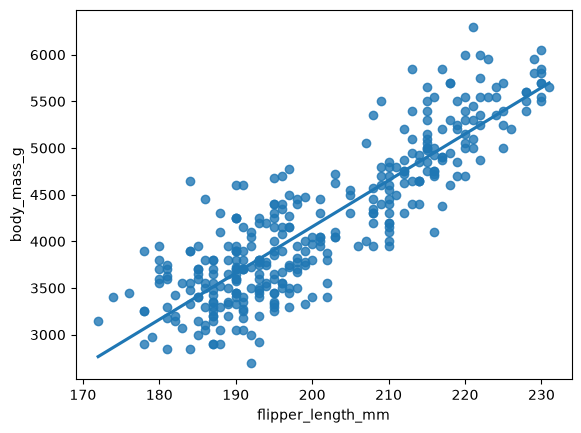

In [4]:
# Now we will do a simple scatterplot of this data.
# Note that you can use regplot or lmplot in seaborn to explore these differences. (See seaborn documentation for details.)

import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=penguins, x="flipper_length_mm", y="body_mass_g", ci=None)


In [5]:
# Now, let's build a simple linear regression model using sklearn.
# We will use flipper_length_mm as the independent variable and body_mass_g as the dependent variable.

from sklearn.linear_model import LinearRegression
X = peng_subset[['flipper_length_mm']]
y = peng_subset['body_mass_g']

model = LinearRegression().fit(X, y)
print(model.coef_, model.intercept_)

print(f"body_mass_g = {model.intercept_:.2f} + {model.coef_[0]:.2f} * flipper_length_mm")
print(f"R^2 = {model.score(X, y):.4f}")

[49.68556641] -5780.831358077063
body_mass_g = -5780.83 + 49.69 * flipper_length_mm
R^2 = 0.7590


In [6]:
# Alternatively you can use statsmodels to build a linear regression model.
# This will give you more information about the model, including p-values and confidence intervals.
# Either is a fine tool to use, though sklearn is more commonly used in production software.

import statsmodels.api as sm

X = sm.add_constant(peng_subset["flipper_length_mm"])
y = peng_subset["body_mass_g"]

results = sm.OLS(y, X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          4.37e-107
Time:                        11:38:47   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.81

In [7]:
# We can also fact check these results with the equations for b0 and b1 that we derived in class. 
# Note that under the hood, sklearn is using matrix decompositions and more computationally efficient
# methods to handle the case of larger numbers. 

import numpy as np

x = peng_subset['flipper_length_mm']
y = peng_subset['body_mass_g']

x_bar, y_bar = x.mean(), y.mean()

b1 = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0 = y_bar - b1 * x_bar

print(f"manual:       b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"sklearn:      b0 = {model.intercept_:.4f}, b1 = {model.coef_[0]:.4f}")
print(f"statsmodels:  b0 = {results.params.iloc[0]:.4f}, b1 = {results.params.iloc[1]:.4f}")

manual:       b0 = -5780.8314, b1 = 49.6856
sklearn:      b0 = -5780.8314, b1 = 49.6856
statsmodels:  b0 = -5780.8314, b1 = 49.6856


In [8]:
# Now that we have this model, for each value of flipper_length, we can predict body_mass

y_hat = model.predict(peng_subset[['flipper_length_mm']])
y_hat

array([3212.25616143, 3460.68399346, 3907.85409111, 3808.4829583 ,
       3659.42625908, 3212.25616143, 3907.85409111, 3808.4829583 ,
       3659.42625908, 3460.68399346, 3162.57059502, 3261.94172783,
       3709.11182549, 4056.91079033, 3410.99842705, 3907.85409111,
       4007.22522392, 3361.31286065, 3858.16852471, 2864.45719658,
       3162.57059502, 3609.74069268, 3410.99842705, 3162.57059502,
       3510.36955986, 3311.62729424, 3510.36955986, 2765.08606377,
       3162.57059502, 3063.19946221, 3063.19946221, 3560.05512627,
       3361.31286065, 3907.85409111, 3957.53965752, 3659.42625908,
       3162.57059502, 3212.25616143, 3361.31286065, 3261.94172783,
       3907.85409111, 3460.68399346, 3957.53965752, 3410.99842705,
       3659.42625908, 3261.94172783, 3112.88502861, 3659.42625908,
       3709.11182549, 3460.68399346, 3560.05512627, 3659.42625908,
       4156.28192314, 3510.36955986, 3709.11182549, 3460.68399346,
       3808.4829583 , 3212.25616143, 3858.16852471, 3410.99842

In [9]:
# We can also compare predicted (y_hat) to actual (body_mass_g) that we already have in the dataset
peng_subset['y_hat'] = y_hat
peng_subset['residuals'] = peng_subset['body_mass_g'] - peng_subset['y_hat']

# Now let's look at y, y_hat, and residuals all together
peng_subset[['body_mass_g', 'y_hat', 'residuals']].head()

# Remember: The values of b0 abd b1 were calculated based on minimizing the residuals via OLS

,body_mass_g,y_hat,residuals
0,3750.0,3212.256161,537.743839
1,3800.0,3460.683993,339.316007
2,3250.0,3907.854091,-657.854091
4,3450.0,3808.482958,-358.482958
5,3650.0,3659.426259,-9.426259


<Axes: xlabel='y_hat', ylabel='body_mass_g'>

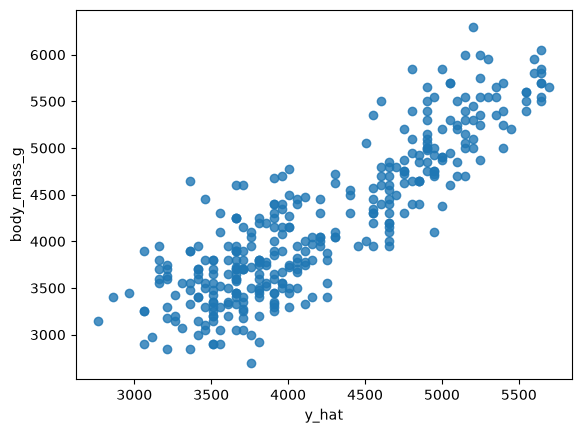

In [10]:
# Let's plot actual vs predicted
sns.regplot(data=peng_subset, x='y_hat', y='body_mass_g', fit_reg=False)


<Axes: xlabel='y_hat', ylabel='residuals'>

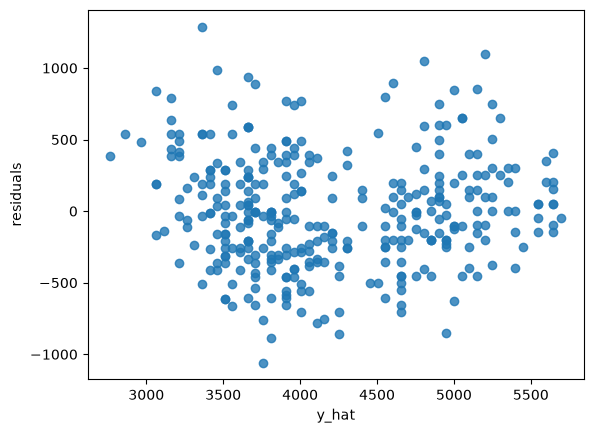

In [11]:
# ...and fitted vs residuals. Looking at fitted vs residuals can help us identify whether a linear model is indeed a good fit. 
# Although we can't necessarily tell if these are normally distributed, obvious patterns in the residuals indicate
# that a linear model is not the ideal fit. 
sns.regplot(data=peng_subset, x='y_hat', y='residuals', fit_reg=False)

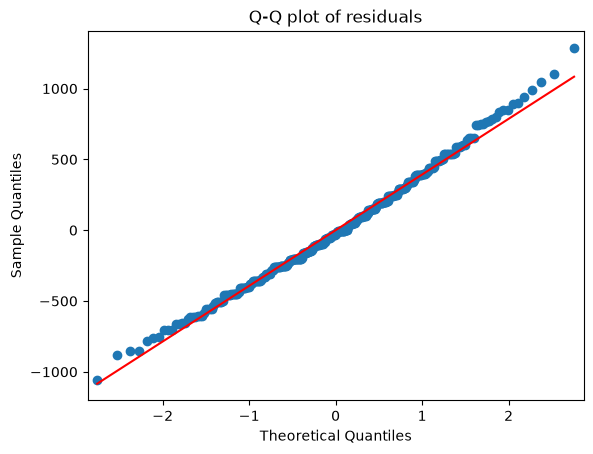

In [12]:
# Because we expect the residuals to be normally distributed, a Q-Q plot gives us
# quantiles of our sample vs quanties in a normal distribution. 
# This will give us a visual of how close we are. 

sm.qqplot(results.resid, line='s')
plt.title('Q-Q plot of residuals')
plt.show()

In [13]:
# Bootstrapping--
# Stats models gave us confidence intervals under the standard assumption that the errors are uncorrelated and normally distributed. 
# We can also use bootstrapping to get estimates for the betas and confidence intervals. 

# We will bootstrap 10000 times and see what we get. This doesn't make any assumptions about the underlying distribution. 


rng = np.random.default_rng(42)   # seed so class results are reproducible
n_boot = 10000
n = len(peng_subset) # number of samples in each simulation

# We will use x and y as defined above and convert to numpy. 
x = peng_subset['flipper_length_mm']
y = peng_subset['body_mass_g']
xv, yv = x.to_numpy(), y.to_numpy()
boot = np.empty((n_boot, 2)) #initialize an array of empty tuples


How should you know when to use bootstrap:


In [14]:
# Now we simulate
for i in range(n_boot):                  # Do this 10000 times
    idx = rng.integers(0, n, n)          # sample n rows WITH replacement
    xb, yb = xv[idx], yv[idx]            # generate pairs of x and y from dataset
    xm, ym = xb.mean(), yb.mean()        # calculate means
    slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum() #calculate b1
    boot[i] = (ym - slope * xm, slope)   # save b0 and b1 for this simulation

In [15]:
# Now we can create a dataframe out of our bootstrap example and look at our mean values and confidence intervals
boot_df = pd.DataFrame(boot, columns=['b0', 'b1'])

# The 95% confidence interval is given by the middle 95% of this distribution
# We can use the quantile function to find this
# We can also compare with the values from statsmodels

analytic_ci = results.conf_int()

comparison = pd.DataFrame({
    'estimate (full sample)': [b0, b1],
    'bootstrap mean':         [boot_df['b0'].mean(), boot_df['b1'].mean()],
    'CI low (formula)':       analytic_ci[0].to_numpy(),
    'CI low (bootstrap)':     [boot_df['b0'].quantile(.025), boot_df['b1'].quantile(.025)],
    'CI high (formula)':      analytic_ci[1].to_numpy(),
    'CI high (bootstrap)':    [boot_df['b0'].quantile(.975), boot_df['b1'].quantile(.975)],
}, index=['b0', 'b1'])

comparison.round(3).T

,b0,b1
estimate (full sample),-5780.831,49.686
bootstrap mean,-5786.496,49.713
CI low (formula),-6382.358,46.699
CI low (bootstrap),-6358.620,46.861
CI high (formula),-5179.305,52.672
CI high (bootstrap),-5205.715,52.530


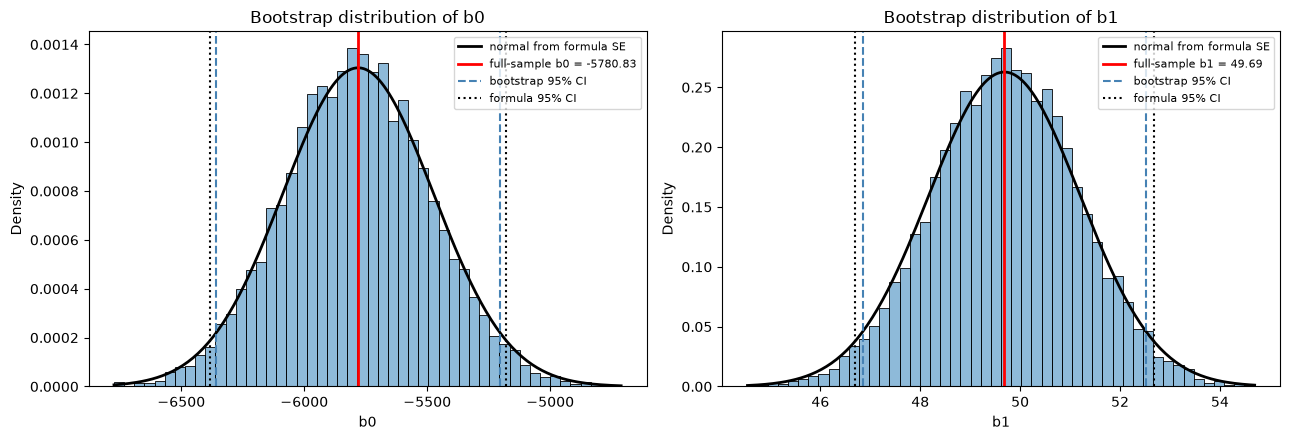

In [16]:
# Now let's visualize this. 

from scipy import stats

analytic_ci = results.conf_int().to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, (ax, coef, est) in enumerate(zip(axes, ['b0', 'b1'], [b0, b1])):
    se = results.bse.iloc[i]
    sns.histplot(boot_df[coef], bins=50, stat='density', ax=ax, alpha=0.5)

    # the normal curve the FORMULA says the estimate should follow
    grid = np.linspace(boot_df[coef].min(), boot_df[coef].max(), 200)
    ax.plot(grid, stats.norm.pdf(grid, est, se), 'k-', lw=2, label='normal from formula SE')

    ax.axvline(est, color='red', lw=2, label=f'full-sample {coef} = {est:.2f}')
    lo, hi = boot_df[coef].quantile([0.025, 0.975])
    ax.axvline(lo, color='steelblue', ls='--', label='bootstrap 95% CI')
    ax.axvline(hi, color='steelblue', ls='--')
    ax.axvline(analytic_ci[i, 0], color='black', ls=':', label='formula 95% CI')
    ax.axvline(analytic_ci[i, 1], color='black', ls=':')

    ax.set_title(f'Bootstrap distribution of {coef}')
    ax.legend(fontsize=8)

plt.tight_layout()